# Stage 1 Baselines

**Objective:** Train and evaluate baseline models on Snorkel-produced weak (probabilistic) labels.

| | |
|---|---|
| **Target** | `renegotiation_prob` (continuous, [0, 1]) |
| **Grouping** | `contract_id` (group-aware train/val split) |
| **Models** | Mean Predictor · Elastic Net · MLP · XGBoost |
| **Primary metric** | MAE (secondary: RMSE, R²) |

All model definitions, training loops, and plotting utilities live in `src/master_thesis/`.  


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print(src_path)

/Users/Thomas/Desktop/Master Thesis/src


## 1 Imports

In [2]:
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from master_thesis.config import DATA_RAW, MODELS_STAGE1, REPORTS, SEED
from master_thesis.baselines import (
    fit_mean_predictor,
    fit_elastic_net,
    fit_xgboost_regressor,
    extract_xgb_feature_importance,
)
from master_thesis.mlp import TabularMLP, train_mlp, predict_mlp
from master_thesis.metrics import evaluate
from master_thesis.plotting import (
    plot_baseline_metric,
    plot_predicted_vs_true,
    save_fig,
)
from master_thesis.mlp import set_seed
from master_thesis.config import SEED

## 2 Load weak-labeled dataset

In [3]:
df = pd.read_csv(DATA_RAW / "contract_snorkel_labeled.csv", low_memory=False) # use when set up again
#df = pd.read_csv(DATA_RAW / "contract_final_no_spend.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Unique contracts: {df['contract_id'].nunique()}")

Shape: (9201, 226)
Unique contracts: 2209


In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,...,global_esg_yes_votes,global_esg_no_votes,global_news_yes_votes,global_news_no_votes,global_market_yes_votes,global_market_no_votes,global_supplier_macro_yes_votes,global_supplier_macro_no_votes,logistics_specific_yes_votes,logistics_specific_no_votes
0,0,0,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
1,1,1,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
2,2,2,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
3,3,3,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
4,4,4,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,1,0,0,0


In [5]:
df.columns.to_list()

['Unnamed: 0.1',
 'Unnamed: 0',
 'contract_id',
 'contract_number',
 'contract_name',
 'contract_status',
 'contract_owner_cost_centre',
 'terminated',
 'term_type',
 'start_date',
 'expiration_date',
 'supplier_id',
 'supplier_number',
 'supplier_display_name',
 'payment_terms',
 'incoterms',
 'contract_currency_code',
 'contract_value',
 'contract_value_dkk',
 'contract_type',
 'nn_contract_type',
 'contract_commodity',
 'team',
 'unit',
 'company_country',
 'days_until_expiry',
 'expiry_range',
 'Preferred_supplier_tag',
 'start_year',
 'expiry_year',
 'open_ended_contract',
 'end_year',
 'start_year_capped',
 'observation_year',
 'years_to_expiry',
 'contract_age_years',
 'expiry_pressure_bucket',
 'department_from_cost_center',
 'department',
 'moodys_bvd_id',
 'fin_moodys_company_name',
 'fin_closing_year',
 'fin_closing_date',
 'fin_created_at_utc',
 'fin_Status',
 'fin_implied_rating',
 'fin_risk_level',
 'fin_financial_level',
 'fin_output_text',
 'fin_Implied_rating - origina

## 3 Dataset sanity checks

In [6]:
# Unique contracts per department
contracts_per_dept = (
    df.groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contracts")
    .sort_values("unique_contracts", ascending=False)
)
print("Unique contracts per department")
display(contracts_per_dept)

Unique contracts per department


,department,unique_contracts
3,Devices & Needles,476
5,Drug Product Outsourcing,300
6,Drug Substance Outsourcing,298
10,Packaging Material,289
13,Raw Materials & Energy,281
12,"Quality, Production Services & Supplies",215
1,Bioprocessing & Raw Materials,113
9,Logistics,95
2,Bioprocessing and Excipients,59
0,"Alliance, Acquisitions & PPM CoE",35


In [7]:
# Rows per department
rows_per_dept = (
    df.groupby("department", dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
print("Rows per department")
display(rows_per_dept)

Rows per department


,department,rows
3,Devices & Needles,2197
13,Raw Materials & Energy,1555
10,Packaging Material,1272
12,"Quality, Production Services & Supplies",1044
6,Drug Substance Outsourcing,943
1,Bioprocessing & Raw Materials,679
5,Drug Product Outsourcing,589
9,Logistics,283
0,"Alliance, Acquisitions & PPM CoE",270
2,Bioprocessing and Excipients,218


In [8]:
# Unique contracts per department per year
pivot = (
    df.groupby(["department", "observation_year"], dropna=False)["contract_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("Unique contracts per department per year")
display(pivot)

Unique contracts per department per year


observation_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
department,,,,,,,,,,,
"Alliance, Acquisitions & PPM CoE",11,12,15,22,24,25,28,31,32,35,35
Bioprocessing & Raw Materials,19,23,23,28,34,41,88,99,104,107,113
Bioprocessing and Excipients,8,8,8,10,11,18,19,23,25,29,59
Devices & Needles,34,38,49,56,80,127,165,347,396,429,476
"Distribution, GxP services & Energy",0,0,0,0,0,0,0,0,0,1,1
Drug Product Outsourcing,1,1,1,1,6,11,16,23,66,163,300
Drug Substance Outsourcing,10,12,15,21,35,59,81,107,134,171,298
Global Strategic Outsourcing & Devices,0,0,0,0,0,0,1,3,3,8,8
HI Warehouse Expansion Program,0,0,0,0,0,0,0,0,4,8,8


## 4  Stage 1 experiment setup

In [ ]:
df_baseline = df.copy()

target_col = "renegotiation_prob"
group_col  = "contract_id"

drop_cols = [
    "Unnamed: 0",
    "contract_id",
    "contract_number",
    "contract_name",
    "supplier_id",
    "supplier_number",
    "supplier_display_name",
    "moodys_bvd_id",
    "Company name Latin alphabet",
    "target_renegotiate",
    "start_date",
    "expiration_date",
]

feature_cols = [
    c for c in df_baseline.columns
    if c not in drop_cols + [target_col]
    and not c.endswith("_yes_votes")
    and not c.endswith("_no_votes")
    and c != "lf_abstain_votes"
]

## 5  Build X, y, groups

In [10]:
feature_cols = [c for c in df_baseline.columns if c not in drop_cols + [target_col]]

X      = df_baseline[feature_cols].copy()
y      = df_baseline[target_col].astype(float).copy()
groups = df_baseline[group_col].copy()

print(f"Features: {X.shape[1]}  |  Rows: {X.shape[0]}")

Features: 198  |  Rows: 9201


## 6 Grouped train / validation split

In [11]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train, X_val         = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
y_train, y_val         = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
train_groups, val_groups = groups.iloc[train_idx].copy(), groups.iloc[val_idx].copy()

print(f"Train rows: {X_train.shape[0]}  |  unique contracts: {train_groups.nunique()}")
print(f"Val   rows: {X_val.shape[0]}    |  unique contracts: {val_groups.nunique()}")

Train rows: 7302  |  unique contracts: 1767
Val   rows: 1899    |  unique contracts: 442


## 7 Numeric and categorical column detection

In [12]:
numeric_cols     = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numeric cols: {len(numeric_cols)}  |  Categorical cols: {len(categorical_cols)}")

Numeric cols: 159  |  Categorical cols: 39


## 8 Preprocessor setup

In [13]:
# Preprocessor for Elastic Net and MLP 
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

# Preprocessor for XGBoost 
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

## 9 Initialize result containers

In [14]:
baseline_results_list = []

baseline_val_predictions = pd.DataFrame({
    "contract_id": val_groups.values,
    "y_true":      y_val.values,
})

---
## 10  Mean Predictor

In [15]:
y_pred_mean, results_mean = fit_mean_predictor(y_train, y_val)

baseline_results_list.append(results_mean)
baseline_val_predictions["mean_predictor"] = y_pred_mean

display(results_mean)

,model,rmse,mae,r2,pred_mean,true_mean
0,Mean Predictor,0.30465,0.242176,-0.008325,0.528869,0.556551


## 11  Elastic Net

In [16]:
enet_model, y_pred_enet, results_enet = fit_elastic_net(
    X_train=X_train, X_val=X_val,
    y_train=y_train, y_val=y_val,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    alpha=0.01, l1_ratio=0.5,
)

baseline_results_list.append(results_enet)
baseline_val_predictions["elastic_net"] = y_pred_enet

display(results_enet)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,rmse,mae,r2,pred_mean,true_mean
0,Elastic Net,0.15725,0.119528,0.731355,0.54422,0.556551


## 12  MLP Baseline

In [17]:
set_seed(SEED)

In [18]:
# — Preprocess to tensors —
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc   = X_val_proc.toarray()

X_train_t = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_proc,   dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [19]:
# — DataLoaders —
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=256, shuffle=False)

In [20]:
# — Model, criterion, optimizer —
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model = TabularMLP(input_dim=X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

In [21]:
# — Train —
mlp_model, mlp_history = train_mlp(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    n_epochs=50,
    patience=5,
)

Epoch 01 | Train Loss: 0.5967 | Val Loss: 0.5314 | Val RMSE: 0.1421 | Val MAE: 0.1052
Epoch 02 | Train Loss: 0.5153 | Val Loss: 0.5147 | Val RMSE: 0.1076 | Val MAE: 0.0628
Epoch 03 | Train Loss: 0.4964 | Val Loss: 0.4745 | Val RMSE: 0.0975 | Val MAE: 0.0469
Epoch 04 | Train Loss: 0.4877 | Val Loss: 0.4817 | Val RMSE: 0.0982 | Val MAE: 0.0414
Epoch 05 | Train Loss: 0.4849 | Val Loss: 0.4614 | Val RMSE: 0.0796 | Val MAE: 0.0342
Epoch 06 | Train Loss: 0.4783 | Val Loss: 0.4632 | Val RMSE: 0.0777 | Val MAE: 0.0320
Epoch 07 | Train Loss: 0.4747 | Val Loss: 0.4681 | Val RMSE: 0.0841 | Val MAE: 0.0311
Epoch 08 | Train Loss: 0.4743 | Val Loss: 0.4794 | Val RMSE: 0.0918 | Val MAE: 0.0324
Epoch 09 | Train Loss: 0.4753 | Val Loss: 0.4652 | Val RMSE: 0.0765 | Val MAE: 0.0283
Epoch 10 | Train Loss: 0.4717 | Val Loss: 0.4654 | Val RMSE: 0.0755 | Val MAE: 0.0262
Early stopping triggered at epoch 10


In [22]:
# — Predict and evaluate —
y_pred_mlp = predict_mlp(mlp_model, val_loader, device)

from master_thesis.baselines import evaluate_predictions
results_mlp = evaluate_predictions(y_val, y_pred_mlp, model_name="MLP")

baseline_results_list.append(results_mlp)
baseline_val_predictions["mlp"] = y_pred_mlp

display(results_mlp)

,model,rmse,mae,r2,pred_mean,true_mean
0,MLP,0.079584,0.034224,0.93119,0.549926,0.556551


In [23]:
# — Save MLP artifacts —
MODELS_STAGE1.mkdir(parents=True, exist_ok=True)

torch.save(mlp_model.state_dict(), MODELS_STAGE1 / "mlp_pretrained.pt")
joblib.dump(preprocessor, MODELS_STAGE1 / "mlp_preprocessor.joblib")
mlp_history.to_csv(MODELS_STAGE1 / "mlp_training_history.csv", index=False)

print("Saved: mlp_pretrained.pt | mlp_preprocessor.joblib | mlp_training_history.csv")
display(mlp_history.tail())

Saved: mlp_pretrained.pt | mlp_preprocessor.joblib | mlp_training_history.csv


,epoch,train_loss,val_loss,val_rmse,val_mae
5,6,0.478272,0.463164,0.077672,0.032011
6,7,0.474670,0.468126,0.084102,0.031082
7,8,0.474299,0.479435,0.091827,0.032421
8,9,0.475280,0.465209,0.076546,0.028334
9,10,0.471667,0.465404,0.075469,0.026167


## 13 XGBoost Baseline

In [24]:
xgb_pipeline, y_pred_xgb, results_xgb = fit_xgboost_regressor(
    X_train=X_train, X_val=X_val,
    y_train=y_train, y_val=y_val,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    n_estimators=300, learning_rate=0.05, max_depth=5,
)

baseline_results_list.append(results_xgb)
baseline_val_predictions["xgboost"] = y_pred_xgb

display(results_xgb)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,rmse,mae,r2,pred_mean,true_mean
0,XGBoost,0.017974,0.006124,0.99649,0.556793,0.556551


In [25]:
xgb_importance = extract_xgb_feature_importance(xgb_pipeline)
print("Top 20 XGBoost features:")
display(xgb_importance.head(20))

Top 20 XGBoost features:


,feature,importance
0,num__contract_age_years,0.230945
1,num__fin_flag_moderate_or_worse_rating,0.205883
2,num__fin_implied_rating_missing_flag,0.097114
3,num__Tracking_Tracing,0.055107
4,num__fin_risk_level_missing_flag,0.052639
5,num__open_ended_contract,0.048031
6,cat__expiry_range_180 days,0.034625
7,num__financial_row_missing_pct,0.022375
8,num__start_year,0.019623
9,num__fin_flag_multiple_financial_stress_signals,0.019606


---
## 14 Baseline comparison table

In [26]:
baseline_results = (
    pd.concat(baseline_results_list, ignore_index=True)
    .sort_values("mae", ascending=True)
    .reset_index(drop=True)
)
display(baseline_results)
display(baseline_val_predictions.head())

,model,rmse,mae,r2,pred_mean,true_mean
0,XGBoost,0.017974,0.006124,0.996490,0.556793,0.556551
1,MLP,0.079584,0.034224,0.931190,0.549926,0.556551
2,Elastic Net,0.157250,0.119528,0.731355,0.544220,0.556551
3,Mean Predictor,0.304650,0.242176,-0.008325,0.528869,0.556551


,contract_id,y_true,mean_predictor,elastic_net,mlp,xgboost
0,8157,0.472363,0.528869,0.425072,0.471852,0.469705
1,8157,0.472363,0.528869,0.477652,0.474916,0.467017
2,8157,0.472363,0.528869,0.530232,0.477601,0.467017
3,8157,0.472363,0.528869,0.582812,0.476139,0.467301
4,8157,0.166042,0.528869,0.383345,0.217031,0.182645


## 15 Baseline comparison plots

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Stage 1 — Validation RMSE'}, ylabel='Validation RMSE'>)

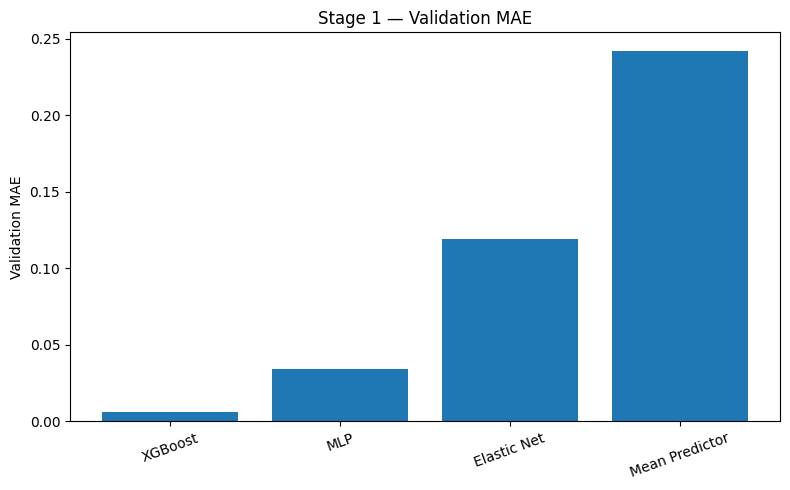

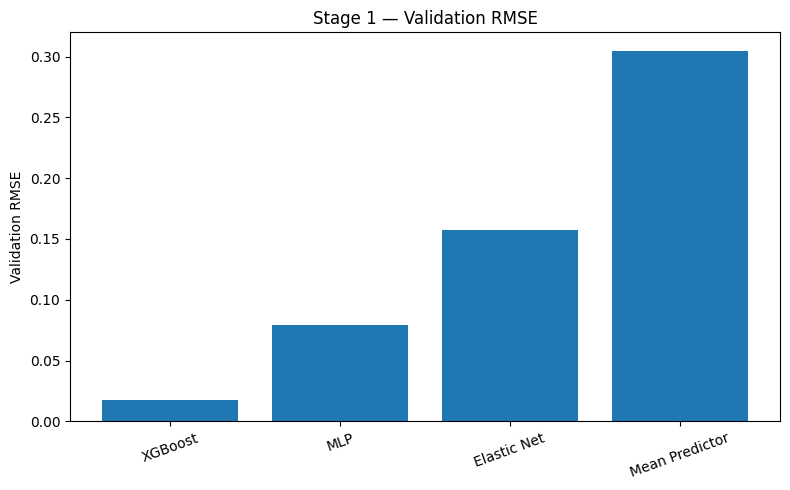

In [27]:
plot_baseline_metric(baseline_results, metric="mae",  title="Stage 1 — Validation MAE")
plot_baseline_metric(baseline_results, metric="rmse", title="Stage 1 — Validation RMSE")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'MLP: Predicted vs True'}, xlabel='True renegotiation_prob', ylabel='Predicted renegotiation_prob'>)

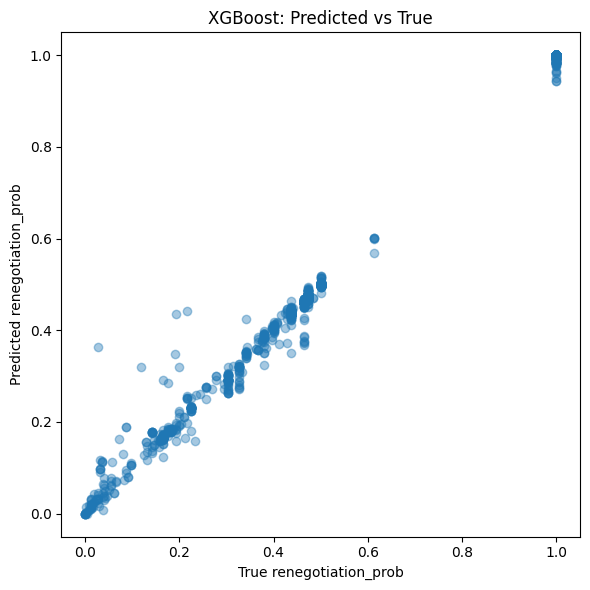

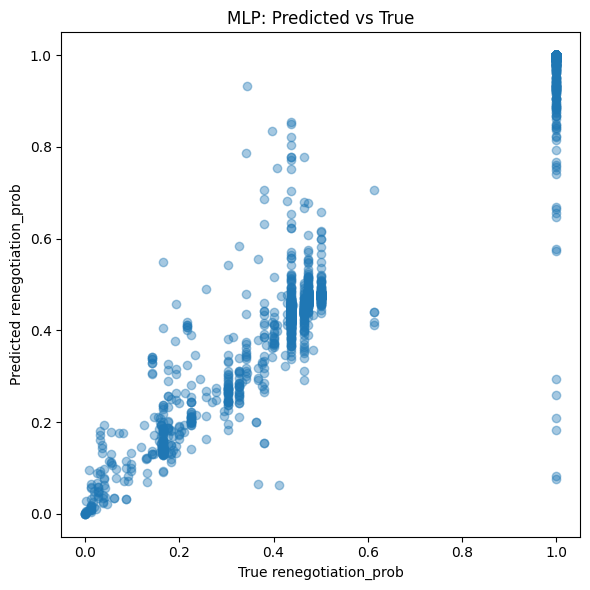

In [28]:
plot_predicted_vs_true(y_val, y_pred_xgb, model_name="XGBoost")
plot_predicted_vs_true(y_val, y_pred_mlp, model_name="MLP")

## 16 Save Stage 1 outputs

In [29]:
tables_dir = REPORTS / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

baseline_results.to_csv(tables_dir / "stage_1_baseline_results.csv", index=False)
baseline_val_predictions.to_csv(tables_dir / "stage_1_val_predictions.csv", index=False)
xgb_importance.to_csv(tables_dir / "xgb_feature_importance.csv", index=False)

print("Saved all Stage A outputs to reports/tables/")

Saved all Stage A outputs to reports/tables/


---
## 17 Interpretation and transition to Stage 2

### Results summary

| Model | Notes |
|---|---|
| **Mean Predictor** | Naive baseline — sets the floor |
| **Elastic Net** | Linear model — captures linear signal from weak labels |
| **MLP** | Neural baseline — needed for Stage 2 fine-tuning and MAML |
| **XGBoost** | Strongest tabular learner on weak labels - Non-linear model |

XGBoost is expected to be the strongest Stage A tabular model due to its robustness to noisy labels and feature interactions.

The MLP is retained regardless of Stage 1 rank because it provides the **neural initialization** needed for Stage 2:
- Fine-tuning on Logistics gold labels (transfer learning baseline)
- MAML / FOMAML meta-adaptation across departments

